In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0125.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0223.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0030.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0141.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0226.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0203.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0048.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0070.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0212.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data1a/validation/00-damage/0002.JPEG
/kaggle/input/datasets/anujms/car-damage-detection/cars/data

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import copy

# Utilisation du GPU si disponible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# Dossier pour sauvegarder le modèle final
if not os.path.exists('/kaggle/working/models'):
    os.makedirs('/kaggle/working/models')

Utilisation du device : cuda:0


In [4]:
# Chemin exact basé sur votre capture d'écran
data_dir = '/kaggle/input/datasets/anujms/car-damage-detection/data1a'

data_transforms = {
    'training': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Utilisation des clés 'training' et 'validation' pour correspondre à vos dossiers
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['training', 'validation']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4)
              for x in ['training', 'validation']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['training', 'validation']}
class_names = image_datasets['training'].classes
num_classes = len(class_names)

print(f"Classes détectées : {class_names}")
# Devrait afficher : ['00-damage', '01-whole']

Classes détectées : ['00-damage', '01-whole']


In [5]:
def train_model(model, criterion, optimizer, scheduler, name, num_epochs=30):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # CORRECTED: Les clés ici doivent correspondre exactement aux phases utilisées
    history = {'training_loss': [], 'validation_loss': [], 'training_acc': [], 'validation_acc': []}
    
    patience = 7
    counter = 0
    best_loss = float('inf')

    for epoch in range(num_epochs):
        print(f'Époque {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Utilisation des noms exacts de vos dossiers Kaggle
        for phase in ['training', 'validation']: 
            if phase == 'training':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # On itère sur les dataloaders chargés précédemment
            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'training'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'training':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'training':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # CORRECTED: Utilisation des clés 'training' et 'validation'
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Early Stopping & Save Best
            if phase == 'validation':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    # Sauvegarde sur le disque Kaggle
                    torch.save(model.state_dict(), f'/kaggle/working/best_{name}.pt')
                
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    counter = 0
                else:
                    counter += 1
        
        if counter >= patience:
            print("Early stopping atteint.")
            break

    time_elapsed = time.time() - since
    print(f'Entraînement terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Meilleure précision Val: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [6]:
# Modèles à tester
models_to_test = {
    "resnet50": models.resnet50(weights='IMAGENET1K_V1'),
    "efficientnet": models.efficientnet_b0(weights='IMAGENET1K_V1'),
    "vit": models.vit_b_16(weights='IMAGENET1K_V1')
}

all_histories = {}

for name, model in models_to_test.items():
    print(f"\n--- Training {name} ---")
    
    # Adaptation de la dernière couche
    if "resnet" in name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif "efficientnet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif "vit" in name:
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    trained_model, history = train_model(model, criterion, optimizer, exp_lr_scheduler, name)
    all_histories[name] = history

# Sauvegarde finale du meilleur des meilleurs
# (Logique simple : on garde le dernier entraîné ou on compare manuellement)


--- Training resnet50 ---
Époque 0/29
----------
training Loss: 0.3073 Acc: 0.8712
validation Loss: 0.2383 Acc: 0.9000
Époque 1/29
----------
training Loss: 0.2193 Acc: 0.9114
validation Loss: 0.1733 Acc: 0.9326
Époque 2/29
----------
training Loss: 0.1880 Acc: 0.9234
validation Loss: 0.1411 Acc: 0.9413
Époque 3/29
----------
training Loss: 0.1672 Acc: 0.9375
validation Loss: 0.1679 Acc: 0.9283
Époque 4/29
----------
training Loss: 0.1538 Acc: 0.9342
validation Loss: 0.2640 Acc: 0.9130
Époque 5/29
----------
training Loss: 0.1785 Acc: 0.9321
validation Loss: 0.2084 Acc: 0.9174
Époque 6/29
----------
training Loss: 0.1455 Acc: 0.9402
validation Loss: 0.1993 Acc: 0.9130
Époque 7/29
----------
training Loss: 0.0976 Acc: 0.9636
validation Loss: 0.1672 Acc: 0.9500
Époque 8/29
----------
training Loss: 0.0918 Acc: 0.9625
validation Loss: 0.1605 Acc: 0.9435
Époque 9/29
----------
training Loss: 0.0827 Acc: 0.9690
validation Loss: 0.1619 Acc: 0.9457
Early stopping atteint.
Entraînement termin

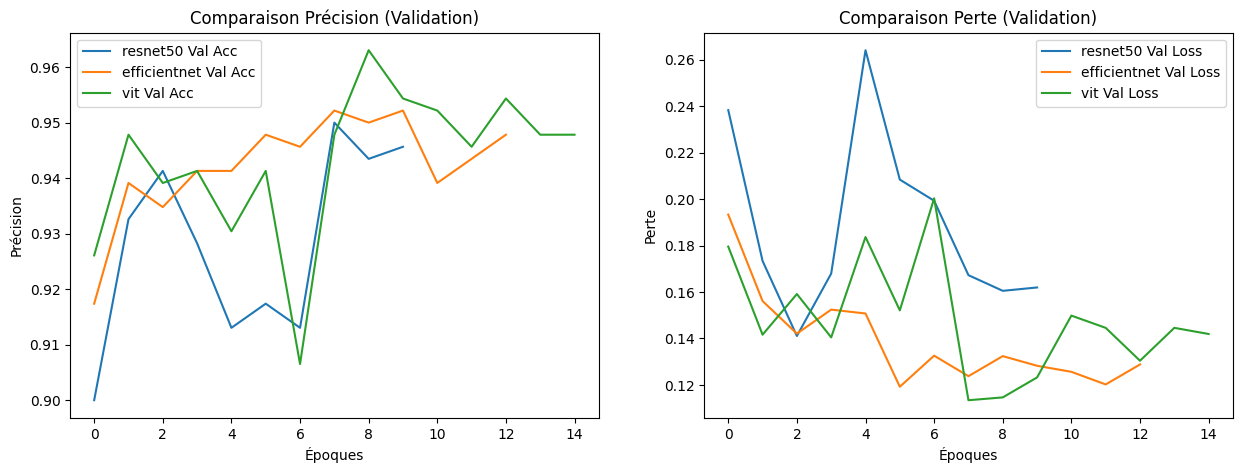

In [8]:
plt.figure(figsize=(15, 5))

# Graphique de Précision
plt.subplot(1, 2, 1)
for name in all_histories:
    # Changement de 'val_acc' vers 'validation_acc'
    plt.plot(all_histories[name]['validation_acc'], label=f'{name} Val Acc')
plt.title('Comparaison Précision (Validation)')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()

# Graphique de Perte
plt.subplot(1, 2, 2)
for name in all_histories:
    # Changement de 'val_loss' vers 'validation_loss'
    plt.plot(all_histories[name]['validation_loss'], label=f'{name} Val Loss')
plt.title('Comparaison Perte (Validation)')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

plt.show()

In [9]:
import shutil

# 1. Identifier le meilleur modèle basé sur les résultats de validation
best_precision = 0
best_model_name = ""

for name in all_histories:
    # On récupère la dernière précision de validation (ou la max)
    current_best = max(all_histories[name]['validation_acc'])
    if current_best > best_precision:
        best_precision = current_best
        best_model_name = name

print(f"Le meilleur modèle est : {best_model_name} avec une précision de {best_precision:.4f}")

# 2. Copier le fichier spécifique vers un nom générique 'best_model.pt'
source_path = f'/kaggle/working/best_{best_model_name}.pt'
destination_path = '/kaggle/working/best_model.pt'

try:
    shutil.copy(source_path, destination_path)
    print(f"Succès ! Le fichier '{destination_path}' est prêt pour votre projet web.")
except FileNotFoundError:
    print("Erreur : Le fichier source n'a pas été trouvé. Vérifiez que l'entraînement s'est terminé.")

# 3. Récapitulatif des fichiers disponibles dans votre dossier de travail
print("\nFichiers dans /kaggle/working/ :")
print(os.listdir('/kaggle/working/'))

Le meilleur modèle est : vit avec une précision de 0.9630
Succès ! Le fichier '/kaggle/working/best_model.pt' est prêt pour votre projet web.

Fichiers dans /kaggle/working/ :
['models', 'best_vit.pt', 'best_model.pt', '.virtual_documents', 'best_efficientnet.pt', 'best_resnet50.pt']


In [ ]:
model.load_state_dict(torch.load('best_efficientnet.pt', map_location=device))
model.eval()